In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("fake reviews dataset.csv")

# See the first few rows
print(df.head())

# Check shape and column names
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check label distribution
print(df['label'].value_counts())

             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  
Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']
label
CG    20216
OR    20216
Name: count, dtype: int64


In [2]:
print(df.columns.tolist())


['category', 'rating', 'label', 'text_']


In [3]:
import re
def clean_text(text):
    text = text.lower()                        # Step 1: Lowercase
    text = re.sub(r'[^a-z\s]', '', text)      # Step 2: Remove punctuation/numbers
    return text

# Apply to correct column name
df['clean_text'] = df['text_'].apply(clean_text)
print(df[['text_', 'clean_text']].head())

                                               text_  \
0  Love this!  Well made, sturdy, and very comfor...   
1  love it, a great upgrade from the original.  I...   
2  This pillow saved my back. I love the look and...   
3  Missing information on how to use it, but it i...   
4  Very nice set. Good quality. We have had the s...   

                                          clean_text  
0  love this  well made sturdy and very comfortab...  
1  love it a great upgrade from the original  ive...  
2  this pillow saved my back i love the look and ...  
3  missing information on how to use it but it is...  
4  very nice set good quality we have had the set...  


In [4]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()                                      # Split sentence into words
    filtered = [w for w in words if w not in stop_words]     # Keep only non-stopwords
    return ' '.join(filtered)                                 # Join back into sentence

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
print(df['clean_text'].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shambhavi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


0    love well made sturdy comfortable love itvery ...
1    love great upgrade original ive mine couple years
2              pillow saved back love look feel pillow
3          missing information use great product price
4                 nice set good quality set two months
Name: clean_text, dtype: object


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)   # Use top 5000 words only

X = vectorizer.fit_transform(df['clean_text'])    # Convert text → numbers
y = df['label']                                   # Target column

print("Shape of X:", X.shape)
print("Sample labels:", y.value_counts())

Shape of X: (40432, 5000)
Sample labels: label
CG    20216
OR    20216
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (32345, 5000)
Testing size: (8087, 5000)


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


MultinomialNB()

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

# Naive Bayes
nb_pred = nb_model.predict(X_test)
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

# Logistic Regression
lr_pred = lr_model.predict(X_test)
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

=== Naive Bayes ===
Accuracy: 0.8528502534932608
              precision    recall  f1-score   support

          CG       0.84      0.87      0.86      4016
          OR       0.87      0.83      0.85      4071

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087

=== Logistic Regression ===
Accuracy: 0.880178063558798
              precision    recall  f1-score   support

          CG       0.89      0.87      0.88      4016
          OR       0.87      0.89      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



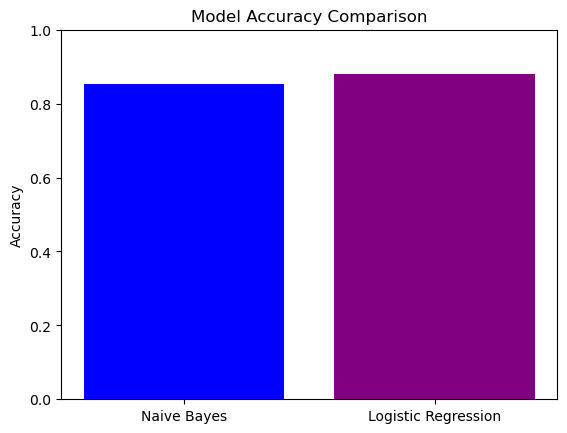

In [22]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression']
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred)
]

plt.bar(models, accuracies, color=['blue', 'purple'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

In [15]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=1000)
svm_model.fit(X_train, y_train)



LinearSVC()

In [17]:
svm_pred = svm_model.predict(X_test)
print("SVM")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM
Accuracy: 0.8833931000370966
              precision    recall  f1-score   support

          CG       0.89      0.88      0.88      4016
          OR       0.88      0.89      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



In [19]:
from sklearn.metrics import confusion_matrix

models = [
    ("Naive Bayes", nb_pred),
    ("Logistic Regression", lr_pred),
    ("SVM", svm_pred)
]

for name, pred in models:
    cm = confusion_matrix(y_test, pred)
    print(f" {name} ")
    print(f"                Predicted CG    Predicted OR")
    print(f"Actual CG           {cm[0][0]}          {cm[0][1]}")
    print(f"Actual OR           {cm[1][0]}          {cm[1][1]}")
    print(f"Correct: {cm[0][0] + cm[1][1]} | Wrong: {cm[0][1] + cm[1][0]}")
    print()

 Naive Bayes 
                Predicted CG    Predicted OR
Actual CG           3509          507
Actual OR           683          3388
Correct: 6897 | Wrong: 1190

 Logistic Regression 
                Predicted CG    Predicted OR
Actual CG           3491          525
Actual OR           444          3627
Correct: 7118 | Wrong: 969

 SVM 
                Predicted CG    Predicted OR
Actual CG           3528          488
Actual OR           455          3616
Correct: 7144 | Wrong: 943



In [24]:
import pickle

# Save Naive Bayes
with open("nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

# Save Logistic Regression
with open("lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Save SVM
with open("svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

# Save Vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

